In [1]:
#Preprocessing the Data
# =========================
# Step 0: Install dependencies
# =========================
!pip install Pillow tqdm

# =========================
# Step 1: Clone your GitHub repo
# =========================
# Replace with your GitHub repo URL
!git clone https://github.com/Nayanapmku/facial_recognition.git

import os
repo_dir = "facial_recognition"  # Replace with your cloned repo folder
os.chdir(repo_dir)

# Check the contents
!ls
# You should see 'dataset/' folder here

# =========================
# Step 2: Imports
# =========================
from PIL import Image
from tqdm import tqdm

# =========================
# Step 3: Define input/output paths
# =========================
dataset_dir = "dataset"  # The folder in your repo containing train/val/test
processed_dir = "processed_data"  # New folder to store preprocessed images
os.makedirs(processed_dir, exist_ok=True)

target_size = (224, 224)  # Resize images
mode = "RGB"               # Convert to RGB

# =========================
# Step 4: Preprocess function
# =========================
def preprocess_and_save(input_dir, output_dir):
    for split in os.listdir(input_dir):  # train, val, test
        split_input_dir = os.path.join(input_dir, split)
        split_output_dir = os.path.join(output_dir, split)
        os.makedirs(split_output_dir, exist_ok=True)

        for person in os.listdir(split_input_dir):
            person_input_dir = os.path.join(split_input_dir, person)
            person_output_dir = os.path.join(split_output_dir, person)
            os.makedirs(person_output_dir, exist_ok=True)

            for img_file in tqdm(os.listdir(person_input_dir), desc=f"Processing {split}/{person}"):
                img_path = os.path.join(person_input_dir, img_file)
                try:
                    img = Image.open(img_path).convert(mode)
                    img = img.resize(target_size)
                    save_path = os.path.join(person_output_dir, img_file)
                    img.save(save_path)
                except Exception as e:
                    print(f"Failed to process {img_path}: {e}")

# =========================
# Step 5: Run preprocessing
# =========================
preprocess_and_save(dataset_dir, processed_dir)
print("✅ Preprocessing complete! Check the processed_data folder.")

!zip -r processed_data.zip processed_data
from google.colab import files
files.download("processed_data.zip")

Cloning into 'facial_recognition'...
remote: Enumerating objects: 216, done.
remote: Counting objects: 100% (216/216), done.
remote: Compressing objects: 100% (206/206), done.
remote: Total 216 (delta 17), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (216/216), 820.19 KiB | 4.69 MiB/s, done.
Resolving deltas: 100% (17/17), done.
dataset  processed_data  README.md


Processing Facial_Recognition_Val/Kim_Clijsters: 100%|██████████| 3/3 [00:00<00:00, 168.76it/s]
Processing Facial_Recognition_Val/Jennifer_Garner: 100%|██████████| 3/3 [00:00<00:00, 134.62it/s]
Processing Facial_Recognition_Train/John_Snow: 100%|██████████| 11/11 [00:00<00:00, 217.90it/s]
Processing Facial_Recognition_Train/Jacques_Rogge: 100%|██████████| 6/6 [00:00<00:00, 128.79it/s]
Processing Facial_Recognition_Train/Kim_Clijsters: 100%|██████████| 8/8 [00:00<00:00, 144.85it/s]
Processing Facial_Recognition_Train/Jennifer_Garner: 100%|██████████| 7/7 [00:00<00:00, 109.79it/s]
Processing Facial_Recognition_Test/Kim_Clijsters: 100%|██████████| 3/3 [00:00<00:00, 221.92it/s]
Processing Facial_Recognition_Test/Jennifer_Garner: 100%|██████████| 2/2 [00:00<00:00, 237.88it/s]


✅ Preprocessing complete! Check the processed_data folder.
  adding: processed_data/ (stored 0%)
  adding: processed_data/Facial_Recognition_Val/ (stored 0%)
  adding: processed_data/Facial_Recognition_Val/John_Snow/ (stored 0%)
  adding: processed_data/Facial_Recognition_Val/John_Snow/John_Snow_0016.jpg (deflated 2%)
  adding: processed_data/Facial_Recognition_Val/John_Snow/John_Snow_0017.jpg (deflated 2%)
  adding: processed_data/Facial_Recognition_Val/John_Snow/John_Snow_0015.jpg (deflated 2%)
  adding: processed_data/Facial_Recognition_Val/Jacques_Rogge/ (stored 0%)
  adding: processed_data/Facial_Recognition_Val/Jacques_Rogge/Jacques_Rogge_0009.jpg (deflated 2%)
  adding: processed_data/Facial_Recognition_Val/Jacques_Rogge/Jacques_Rogge_0010.jpg (deflated 2%)
  adding: processed_data/Facial_Recognition_Val/Kim_Clijsters/ (stored 0%)
  adding: processed_data/Facial_Recognition_Val/Kim_Clijsters/Kim_Clijsters_0013.jpg (deflated 2%)
  adding: processed_data/Facial_Recognition_Val/Kim

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [2]:
# Install Necessary Libraries
!pip install face_recognition opencv-python scikit-learn matplotlib seaborn

In [3]:
# Clone GitHub Repository
!git clone https://github.com/Nayanapmku/facial_recognition.git

import os
os.chdir("facial_recognition")

!ls

Cloning into 'facial_recognition'...
remote: Enumerating objects: 216, done.
remote: Counting objects: 100% (216/216), done.
remote: Compressing objects: 100% (206/206), done.
remote: Total 216 (delta 17), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (216/216), 820.19 KiB | 4.27 MiB/s, done.
Resolving deltas: 100% (17/17), done.
dataset  processed_data  README.md


In [4]:
# Define Dataset Paths
train_dir = "processed_data/Facial_Recognition_Train"
val_dir = "processed_data/Facial_Recognition_Val"
test_dir = "processed_data/Facial_Recognition_Test"

print(os.listdir("processed_data"))

['Facial_Recognition_Val', 'Facial_Recognition_Train', 'Facial_Recognition_Test']


In [6]:
# Install Libraries and Modules
!pip install face_recognition dlib cmake
!pip install opencv-python scikit-learn matplotlib seaborn


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.1/100.1 MB 8.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for face-recognition-models: filename=face_recognition_models-0.3.0-py2.py3-none-any.whl size=100566166 sha256=b926097fd2c63b68affa9f9e36f52917c297830c488148ec2463802a20052356
  Stored in directory: /root/.cache/pip/wheels/8f/47/c8/f44c5aebb7507f7c8a2c0bd23151d732d0f0bd6884ad4ac635
Successfully built face-recognition-models


In [8]:
# Restart the Runtime
import importlib
import face_recognition # Added this line
importlib.reload(face_recognition)

<module 'face_recognition' from '/usr/local/lib/python3.12/dist-packages/face_recognition/__init__.py'>

In [9]:
# Import Libraries
import face_recognition
import numpy as np
import cv2
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
# Load Dataset and Extract Embeddings
def load_dataset(dataset_path):

    X = []
    y = []

    for person in os.listdir(dataset_path):

        person_path = os.path.join(dataset_path, person)

        for image_name in os.listdir(person_path):

            img_path = os.path.join(person_path, image_name)

            image = face_recognition.load_image_file(img_path)

            face_locations = face_recognition.face_locations(image)

            if len(face_locations) == 0:
                continue

            encodings = face_recognition.face_encodings(image, face_locations)

            for encoding in encodings:
                X.append(encoding)
                y.append(person)

    return np.array(X), np.array(y)

In [11]:
# Extract Training Embeddings
print("Extracting training embeddings...")

X_train, y_train = load_dataset(train_dir)

print("Training samples:", len(X_train))

Extracting training embeddings...
Training samples: 32


In [12]:
# Train KNN Model
knn = KNeighborsClassifier(n_neighbors=3)

knn.fit(X_train, y_train)

print("Model training complete.")

Model training complete.


In [13]:
# Validation Step
print("Extracting validation embeddings...")

X_val, y_val = load_dataset(val_dir)

y_pred_val = knn.predict(X_val)

val_accuracy = accuracy_score(y_val, y_pred_val)

print("Validation Accuracy:", val_accuracy)

Extracting validation embeddings...
Validation Accuracy: 1.0


In [14]:
# Test the Model
print("Extracting test embeddings...")

X_test, y_test = load_dataset(test_dir)

y_pred_test = knn.predict(X_test)

test_accuracy = accuracy_score(y_test, y_pred_test)

print("Test Accuracy:", test_accuracy)

Extracting test embeddings...
Test Accuracy: 1.0


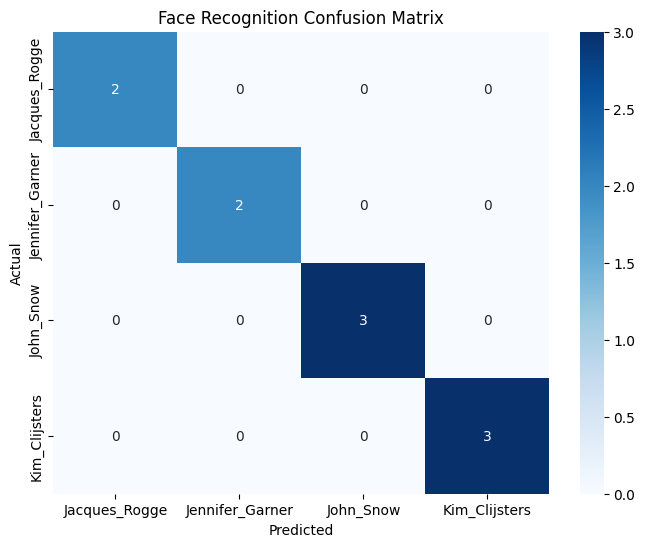

In [15]:
# Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(8,6))

sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=np.unique(y_test),
            yticklabels=np.unique(y_test))

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Face Recognition Confusion Matrix")

plt.show()

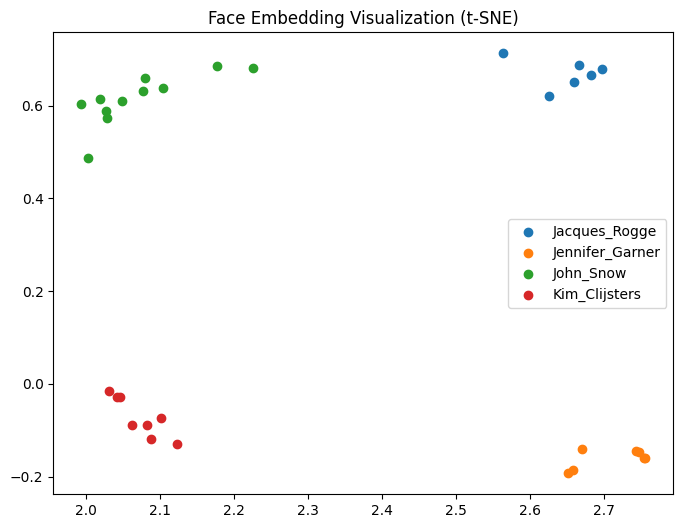

In [16]:
# Embedding Visualization (t-SNE)
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42)

X_embedded = tsne.fit_transform(X_train)

plt.figure(figsize=(8,6))

for label in np.unique(y_train):

    idx = y_train == label
    plt.scatter(X_embedded[idx,0], X_embedded[idx,1], label=label)

plt.legend()
plt.title("Face Embedding Visualization (t-SNE)")
plt.show()

In [18]:
# Test With a Single Image
def predict_image(image_path):

    image = face_recognition.load_image_file(image_path)

    face_locations = face_recognition.face_locations(image)

    encodings = face_recognition.face_encodings(image, face_locations)

    for encoding in encodings:

        prediction = knn.predict([encoding])[0]

        print("Predicted person:", prediction)

predict_image("processed_data/Facial_Recognition_Test/Jacques_Rogge/Jacques_Rogge_0008.jpg")

Predicted person: Jacques_Rogge


In [19]:
# Upload Image From Local Device To Test the Model
from google.colab import files
uploaded = files.upload()

Saving images.webp to images.webp


Predicted Person: Kim_Clijsters


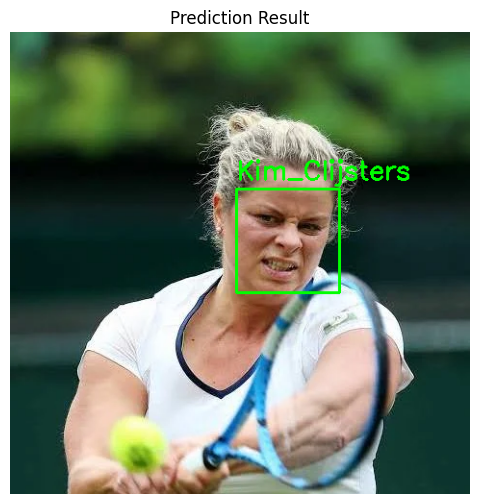

In [20]:
# Run Face Detection + Prediction on Uploaded Image
import matplotlib.pyplot as plt

for filename in uploaded.keys():

    image_path = filename

    # Load image
    image = face_recognition.load_image_file(image_path)

    # Detect faces
    face_locations = face_recognition.face_locations(image)

    # Extract embeddings
    encodings = face_recognition.face_encodings(image, face_locations)

    image_cv = cv2.imread(image_path)

    for (top, right, bottom, left), encoding in zip(face_locations, encodings):

        prediction = knn.predict([encoding])[0]

        # Draw bounding box
        cv2.rectangle(image_cv, (left, top), (right, bottom), (0,255,0), 2)

        # Put label
        cv2.putText(image_cv,
                    prediction,
                    (left, top-10),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.9,
                    (0,255,0),
                    2)

        print("Predicted Person:", prediction)

    # Convert BGR → RGB for plotting
    image_rgb = cv2.cvtColor(image_cv, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(6,6))
    plt.imshow(image_rgb)
    plt.axis("off")
    plt.title("Prediction Result")
    plt.show()